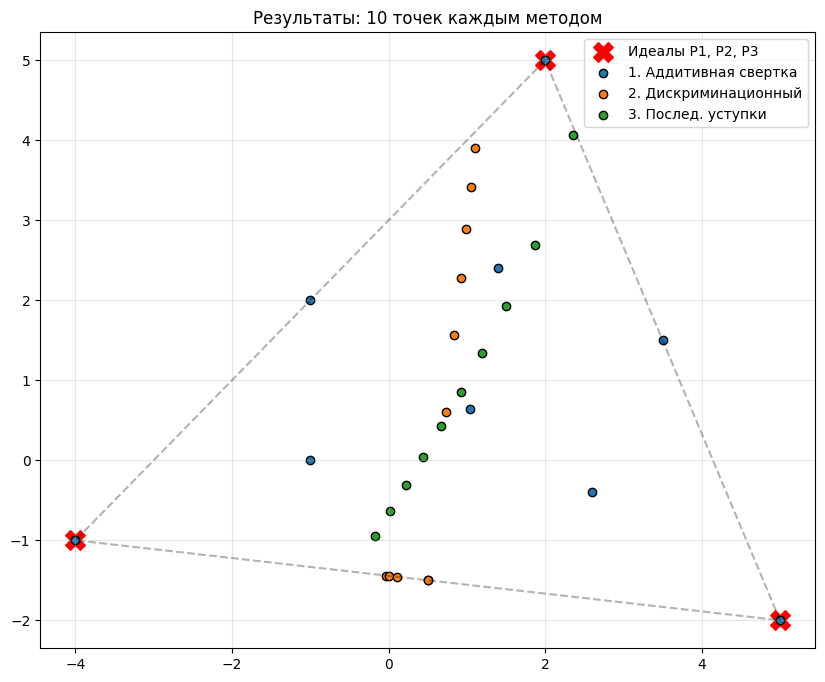

In [1]:
from lab5.additive_convolution_method import additive_convolution_method
from lab5.discriminant_method import minimize_with_discriminant_method
from lab5.sequential_concessions import minimize_with_sequential_concessions
from matplotlib import pyplot as plt
import numpy as np

centers = [(2, 5), (-4, -1), (5, -2)] # b_i, d_i

def f_base(i, x):
    b, d = centers[i]
    return (x[0] - b)**2 + (x[1] - d)**2

f1 = lambda x: f_base(0, x)
f2 = lambda x: f_base(1, x)
f3 = lambda x: f_base(2, x)
funcs_list = [f1, f2, f3]

x0 = np.array([0, 0])

manual_weights = [
    [1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0],
    [0.5, 0.5, 0.0], [0.5, 0.0, 0.5], [0.0, 0.5, 0.5],
    [0.33, 0.33, 0.34], [0.6, 0.2, 0.2], [0.2, 0.6, 0.2], [0.2, 0.2, 0.6]
]

manual_limits = np.linspace(5, 50, 10)

# 3. Уступки для последовательного (от f1 к f2)
manual_deltas = np.linspace(1, 40, 10)

# --- ГЕНЕРАЦИЯ ---

pts_add, pts_disc, pts_seq = [], [], []

for i in range(10):

    pts_add.append(additive_convolution_method(funcs_list, manual_weights[i], x0))


    L = manual_limits[i]
    pts_disc.append(minimize_with_discriminant_method({f1: 1.0}, {f2: L, f3: L}, x0))


    pts_seq.append(minimize_with_sequential_concessions(funcs_list, x0, [manual_deltas[i], 10.0]))



plt.figure(figsize=(10, 8))
cx, cy = zip(*centers)
plt.scatter(cx, cy, c='red', marker='X', s=200, label='Идеалы P1, P2, P3')

p1, p2, p3 = np.array(pts_add), np.array(pts_disc), np.array(pts_seq)
plt.scatter(p1[:,0], p1[:,1], label='1. Аддитивная свертка', edgecolors='k')
plt.scatter(p2[:,0], p2[:,1], label='2. Дискриминационный', edgecolors='k')
plt.scatter(p3[:,0], p3[:,1], label='3. Послед. уступки', edgecolors='k')


plt.plot([cx[0], cx[1], cx[2], cx[0]], [cy[0], cy[1], cy[2], cy[0]], 'k--', alpha=0.3)

plt.title("Результаты: 10 точек каждым методом")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()